<a href="https://colab.research.google.com/github/DahianaRH/LabSO-4/blob/main/analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3.1 Análisis de Rendimiento — Cálculo Paralelo de $\pi$

**Sección 1: Análisis de $\pi$**

Este notebook compila las versiones serial (`pi_s`) y paralela con pthreads (`pi_p`),
ejecuta las mediciones de tiempo, calcula las métricas de rendimiento
(**Speedup** y **Eficiencia**) y produce la tabla y el gráfico solicitados.

La integral base es:

$$\int_{0}^{1} \frac{4}{1+x^2}\,dx = \pi$$

aproximada mediante la **regla del punto medio** con $f(x) = \dfrac{4}{1+x^2}$.

Parámetro del experimento: $n = 2\,000\,000\,000$.



### 0. Configuración e imports

In [2]:
import os, re, subprocess, platform, shutil
import pandas as pd
import matplotlib.pyplot as plt

N_FIJO = 2_000_000_000      # n requerido por la actividad
SRC_SERIAL   = "pi.c"
SRC_PARALLEL = "pi_p.c"
BIN_SERIAL   = "./pi_s"
BIN_PARALLEL = "./pi_p"
REPETICIONES = 3            # se toma el MÍNIMO de cada serie (menos ruido del SO)

print("SO:", platform.platform())
print("Procesador:", platform.processor() or "n/d")


SO: Linux-6.6.122+-x86_64-with-glibc2.35
Procesador: x86_64


### Detección de núcleos y rango de hilos

`os.cpu_count()` devuelve los núcleos lógicos disponibles. La actividad pide variar
$N = 1, 2, 4, 8, \dots$ hasta **2× el número de núcleos**. Construimos esa lista de
potencias de 2 automáticamente.


In [3]:
nucleos = os.cpu_count() or 1
tope = nucleos * 2

hilos_lista = []
N = 1
while N <= tope:
    hilos_lista.append(N)
    N *= 2
# Garantizar que el tope (2x núcleos) quede incluido aunque no sea potencia de 2
if hilos_lista[-1] != tope:
    hilos_lista.append(tope)

print(f"Núcleos lógicos detectados: {nucleos}")
print(f"Tope de hilos (2x núcleos): {tope}")
print(f"Configuraciones de N a evaluar: {hilos_lista}")


Núcleos lógicos detectados: 2
Tope de hilos (2x núcleos): 4
Configuraciones de N a evaluar: [1, 2, 4]


### Compilación


```
gcc -o pi_s pi.c -lm
gcc -o pi_p pi_p.c -lpthread -lm
```


In [4]:
%%writefile pi.c
#include <stdio.h>
#include <stdlib.h>
#include <sys/time.h>

double f(double x) {
    return 4.0 / (1.0 + x * x);
}

double CalcPi(long n) {
    double h = 1.0 / (double) n;
    double sum = 0.0;
    for (long i = 0; i < n; i++) {
        double x = h * ((double) i + 0.5);  /* punto medio */
        sum += f(x);
    }
    return h * sum;
}

int main(int argc, char *argv[]) {
    long n = 2000000000L;          /* valor por defecto */
    if (argc == 2) n = atol(argv[1]);

    struct timeval start, end;
    gettimeofday(&start, NULL);
    double pi = CalcPi(n);
    gettimeofday(&end, NULL);

    double elapsed = (end.tv_sec - start.tv_sec) +
                     (end.tv_usec - start.tv_usec) / 1.0e6;

    printf("n = %ld\n", n);
    printf("PI = %.15f\n", pi);
    printf("TIME = %.6f\n", elapsed);   /* linea parseable por el notebook */
    return 0;
}

Writing pi.c


In [5]:
%%writefile pi_p.c
#include <stdio.h>
#include <stdlib.h>
#include <pthread.h>
#include <sys/time.h>

double fH;        /* h = 1/n, solo lectura en los hilos */
long   n;
int    T;

typedef struct {
    int  tid;
    long start;   /* inclusiva  */
    long end;     /* exclusiva  */
} ThreadArg;

double f(double x) {
    return 4.0 / (1.0 + x * x);
}

void *worker(void *arg) {
    ThreadArg *a = (ThreadArg *) arg;
    double local_sum = 0.0;
    for (long i = a->start; i < a->end; i++) {
        double x = fH * ((double) i + 0.5);
        local_sum += f(x);
    }
    double *result = malloc(sizeof(double));
    *result = local_sum;
    return (void *) result;   /* retorno parcial via pthread_join */
}

int main(int argc, char *argv[]) {
    if (argc < 2) {
        fprintf(stderr, "Uso: %s <num_hilos> [n]\n", argv[0]);
        return 1;
    }
    T = atoi(argv[1]);
    if (T <= 0) {
        fprintf(stderr, "Error: el numero de hilos debe ser > 0\n");
        return 1;
    }
    n = (argc >= 3) ? atol(argv[2]) : 2000000000L;

    fH = 1.0 / (double) n;

    pthread_t *threads = malloc(T * sizeof(pthread_t));
    ThreadArg *args    = malloc(T * sizeof(ThreadArg));

    /* Particion en bloques contiguos; el residuo se reparte de a 1 */
    long base = n / T;
    long rem  = n % T;
    long offset = 0;

    struct timeval start, end;
    gettimeofday(&start, NULL);   /* inicio: antes de crear hilos */

    for (int t = 0; t < T; t++) {
        long chunk = base + (t < rem ? 1 : 0);
        args[t].tid   = t;
        args[t].start = offset;
        args[t].end   = offset + chunk;
        offset += chunk;
        pthread_create(&threads[t], NULL, worker, &args[t]);
    }

    double total = 0.0;
    for (int t = 0; t < T; t++) {
        void *ret;
        pthread_join(threads[t], &ret);
        total += *(double *) ret;
        free(ret);
    }

    double pi = fH * total;       /* reduccion final */

    gettimeofday(&end, NULL);     /* fin: tras la reduccion */

    double elapsed = (end.tv_sec - start.tv_sec) +
                     (end.tv_usec - start.tv_usec) / 1.0e6;

    printf("Hilos = %d\n", T);
    printf("n = %ld\n", n);
    printf("PI = %.15f\n", pi);
    printf("TIME = %.6f\n", elapsed);   /* linea parseable */

    free(threads);
    free(args);
    return 0;
}

Writing pi_p.c


In [6]:
def run(cmd):
    print(">", " ".join(cmd))
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.stdout: print(r.stdout, end="")
    if r.returncode != 0:
        print(r.stderr)
        raise RuntimeError(f"Fallo: {' '.join(cmd)}")
    return r

assert shutil.which("gcc"), "gcc no está instalado"
run(["gcc", "-o", "pi_s", SRC_SERIAL, "-lm"])
run(["gcc", "-o", "pi_p", SRC_PARALLEL, "-lpthread", "-lm"])
print("Compilación OK")


> gcc -o pi_s pi.c -lm
> gcc -o pi_p pi_p.c -lpthread -lm
Compilación OK


### Funciones de ejecución y parseo

Cada binario imprime una línea `TIME = <segundos>` que extraemos con regex. Se ejecuta
varias veces y se conserva el **tiempo mínimo**, que es la estimación más limpia del
costo de cómputo (descarta interferencia puntual del planificador del SO).


In [7]:
TIME_RE = re.compile(r"TIME\s*=\s*([0-9.]+)")
PI_RE   = re.compile(r"PI\s*=\s*([0-9.]+)")

def medir(cmd, reps=REPETICIONES):
    tiempos, pi_val = [], None
    for _ in range(reps):
        out = subprocess.run(cmd, capture_output=True, text=True, check=True).stdout
        tiempos.append(float(TIME_RE.search(out).group(1)))
        pi_val = float(PI_RE.search(out).group(1))
    return min(tiempos), pi_val


### 1. Evaluación del Tiempo Serial $T_s$

Se ejecuta `./pi_s` con $n = 2\,000\,000\,000$.


In [8]:
cmd_serial = [BIN_SERIAL, str(N_FIJO)]
Ts, pi_serial = medir(cmd_serial)
print(f"T_s = {Ts:.6f} s")
print(f"PI (serial) = {pi_serial:.15f}")


T_s = 10.728719 s
PI (serial) = 3.141592653589839


### 2. Evaluación del Tiempo Paralelo $T_p(N)$

Se ejecuta `./pi_p <N> 2000000000` para cada $N$ de la lista detectada.


In [9]:
filas = []
for nt in hilos_lista:
    tp, pi_p = medir([BIN_PARALLEL, str(nt), str(N_FIJO)])
    speedup    = Ts / tp
    eficiencia = speedup / nt
    filas.append({
        "N (Hilos)": nt,
        "Tp (segundos)": tp,
        "Speedup (Ts/Tp)": speedup,
        "Eficiencia (Speedup/N)": eficiencia,
        "PI": pi_p,
    })
    print(f"N={nt:>3}  Tp={tp:8.4f}s  Speedup={speedup:6.3f}  Efic={eficiencia:6.3f}")


N=  1  Tp= 11.0358s  Speedup= 0.972  Efic= 0.972
N=  2  Tp= 11.4229s  Speedup= 0.939  Efic= 0.470
N=  4  Tp= 10.7130s  Speedup= 1.001  Efic= 0.250


### 3. Tabla de Resultados

In [10]:
df = pd.DataFrame(filas)
tabla = df[["N (Hilos)", "Tp (segundos)", "Speedup (Ts/Tp)", "Eficiencia (Speedup/N)"]].copy()
tabla_fmt = tabla.copy()
tabla_fmt["Tp (segundos)"]          = tabla_fmt["Tp (segundos)"].map(lambda v: f"{v:.4f}")
tabla_fmt["Speedup (Ts/Tp)"]        = tabla_fmt["Speedup (Ts/Tp)"].map(lambda v: f"{v:.3f}")
tabla_fmt["Eficiencia (Speedup/N)"] = tabla_fmt["Eficiencia (Speedup/N)"].map(lambda v: f"{v:.3f}")
print(f"T_s = {Ts:.4f} s\n")
tabla_fmt


T_s = 10.7287 s



,N (Hilos),Tp (segundos),Speedup (Ts/Tp),Eficiencia (Speedup/N)
0,1,11.0358,0.972,0.972
1,2,11.4229,0.939,0.470
2,4,10.7130,1.001,0.250


### 4. Gráfico de Speedup ($N$ Hilos vs. Speedup)

Se incluye la línea de **Speedup ideal** ($\text{speedup} = N$) como referencia.


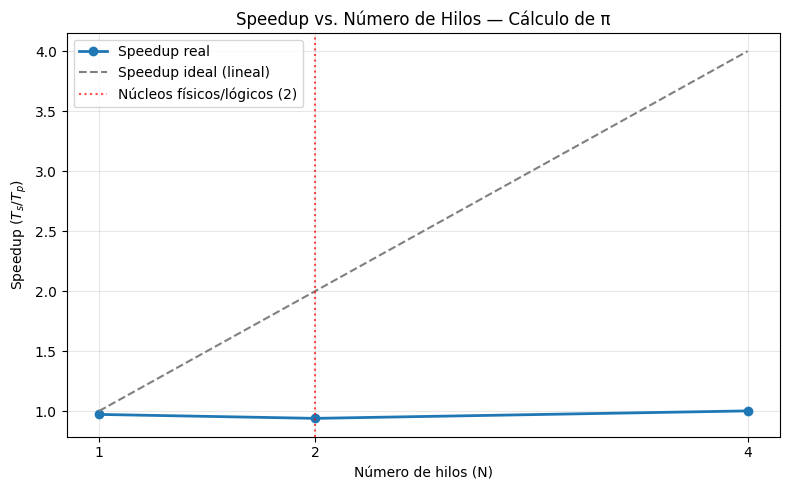

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df["N (Hilos)"], df["Speedup (Ts/Tp)"], marker="o", linewidth=2, label="Speedup real")
ax.plot(df["N (Hilos)"], df["N (Hilos)"], linestyle="--", color="gray", label="Speedup ideal (lineal)")
ax.axvline(nucleos, color="red", linestyle=":", alpha=0.7, label=f"Núcleos físicos/lógicos ({nucleos})")
ax.set_xlabel("Número de hilos (N)")
ax.set_ylabel("Speedup ($T_s / T_p$)")
ax.set_title("Speedup vs. Número de Hilos — Cálculo de π")
ax.set_xticks(df["N (Hilos)"])
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


### 5. Gráfico de Eficiencia (complementario)

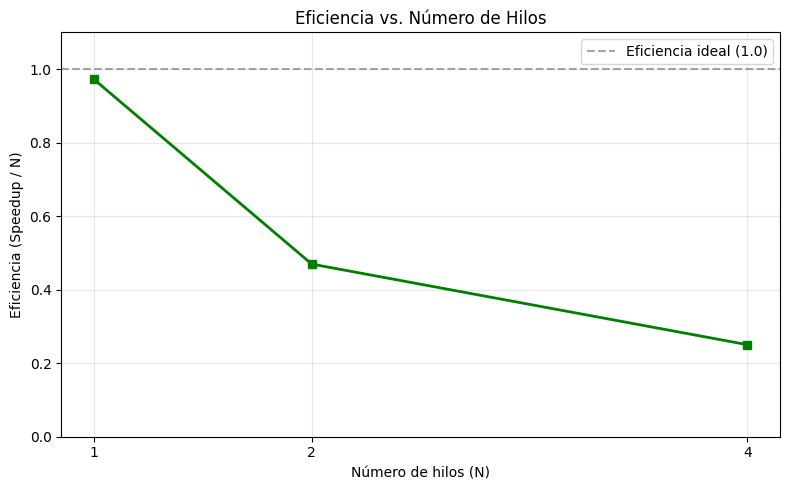

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df["N (Hilos)"], df["Eficiencia (Speedup/N)"], marker="s", color="green", linewidth=2)
ax.axhline(1.0, linestyle="--", color="gray", alpha=0.7, label="Eficiencia ideal (1.0)")
ax.set_xlabel("Número de hilos (N)")
ax.set_ylabel("Eficiencia (Speedup / N)")
ax.set_title("Eficiencia vs. Número de Hilos")
ax.set_xticks(df["N (Hilos)"])
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


### 6. Análisis de Resultados

> Las celdas de abajo extraen automáticamente las cifras clave para que el análisis
> escrito quede respaldado por los datos reales de tu corrida. Ajusta el texto en
> *cursiva* según lo observado.


In [13]:
tp1   = df.loc[df["N (Hilos)"] == 1, "Tp (segundos)"].iloc[0]
mejor = df.loc[df["Speedup (Ts/Tp)"].idxmax()]
overhead_pct = (tp1 - Ts) / Ts * 100

print(f"T_s            = {Ts:.4f} s")
print(f"T_p(1)         = {tp1:.4f} s")
print(f"Overhead T_p(1) vs T_s = {overhead_pct:+.2f} %")
print(f"Speedup máximo = {mejor['Speedup (Ts/Tp)']:.3f}  con N={int(mejor['N (Hilos)'])} hilos")
print(f"Núcleos        = {nucleos}")
print(f"Eficiencia en el tope (N={int(df['N (Hilos)'].iloc[-1])}) = "
      f"{df['Eficiencia (Speedup/N)'].iloc[-1]:.3f}")


T_s            = 10.7287 s
T_p(1)         = 11.0358 s
Overhead T_p(1) vs T_s = +2.86 %
Speedup máximo = 1.001  con N=4 hilos
Núcleos        = 2
Eficiencia en el tope (N=4) = 0.250


### 6.1 Comparación $T_p(1)$ vs $T_s$ (overhead)

$T_p(1)$ ejecuta el mismo trabajo que la versión serial, pero pagando el costo extra de
crear un hilo, hacer `pthread_join`, reservar/liberar memoria del resultado parcial y
la indirección a través de la estructura `ThreadArg`. Por eso $T_p(1)$ suele ser
**ligeramente mayor** que $T_s$ (overhead positivo). Si en tu corrida la diferencia es
pequeña (típicamente < 5 %), indica que el overhead de gestión de un solo hilo es
despreciable frente al cómputo de $2\times10^9$ iteraciones.

*Discrepancia observada: ver el `overhead_pct` impreso arriba.*

### 6.2 Speedup máximo vs. núcleos físicos

El problema es **embarazosamente paralelo**: cada hilo suma un sub-rango disjunto sin
comunicación ni secciones críticas dentro del bucle (la reducción es secuencial y
$O(N)$, insignificante). Por eso el speedup crece casi linealmente **hasta saturar los
núcleos físicos**. A partir de ahí:

- Entre *núcleos físicos* y *2× núcleos* el speedup sigue subiendo poco o se aplana,
  porque los hilos extra compiten por las mismas unidades de ejecución
  (hyper-threading aporta ganancias marginales en cargas limitadas por cómputo en FPU).
- Más allá de $2\times$ núcleos no habría más recursos físicos, solo más contención.

*Compara el `Speedup máximo` impreso con el número de núcleos detectado.*

### 6.3 Tendencia de la eficiencia

La eficiencia ($\text{Speedup}/N$) parte cerca de 1.0 y **decrece** conforme $N$ aumenta.
Causas principales:

1. **Ley de Amdahl:** la fracción serial (creación de hilos + reducción final + I/O)
   no se paraleliza y limita la ganancia asintótica.
2. **Saturación de hardware:** una vez ocupados todos los núcleos físicos, añadir hilos
   reparte el mismo cómputo en más unidades lógicas sin más capacidad real.
3. **Overhead de gestión:** crear y unir más hilos cuesta más; con $N$ grande ese costo
   fijo pesa relativamente más.
4. **Efectos de memoria/planificador:** mayor presión sobre caché y migraciones de
   hilos entre núcleos.

La caída más marcada suele aparecer justo al pasar del número de núcleos físicos hacia
$2\times$, lo que confirma el límite impuesto por el hardware.


### 7. Verificación de correctitud

Todas las versiones deben converger al mismo valor de $\pi$ (pequeñas diferencias en los
últimos dígitos son normales por el orden de la suma en coma flotante).


In [14]:
import math
print(f"PI serial        : {pi_serial:.15f}")
print(f"PI paralelo (máx): {df['PI'].iloc[-1]:.15f}")
print(f"PI math.pi       : {math.pi:.15f}")
print(f"Error abs serial : {abs(pi_serial - math.pi):.2e}")


PI serial        : 3.141592653589839
PI paralelo (máx): 3.141592653589803
PI math.pi       : 3.141592653589793
Error abs serial : 4.57e-14


# 3.2 Análisis de la Generación de la Secuencia de Fibonacci

**Sección 2: Análisis de Fibonacci**

Este notebook presenta la implementación de un generador de la secuencia de Fibonacci utilizando la biblioteca Pthreads en lenguaje C. El programa emplea un hilo trabajador para calcular los primeros N elementos de la secuencia y almacenarlos en un arreglo compartido, mientras que el hilo principal coordina la ejecución y muestra los resultados obtenidos.

La secuencia de Fibonacci se define de forma recursiva como:

F(-2)=0,

F(-1)=1,

F(n)=F(n-1)+F(n-2)   (n>=0)

En esta sección se verificará el correcto funcionamiento del programa mediante la generación de los primeros 15 elementos de la secuencia y se analizarán aspectos relacionados con la transferencia de datos entre hilos, la sincronización mediante `pthread_join`. y el comportamiento de una versión secuencial para valores grandes de N.

### 0. Configuración e Imports

In [15]:
import time
print("SO:", platform.platform())
print("Procesador:", platform.processor() or "n/d")

SO: Linux-6.6.122+-x86_64-with-glibc2.35
Procesador: x86_64


### 1. Implementación de Pthreads

In [16]:
%%writefile fibonacci.c

#include <stdio.h>
#include <stdlib.h>
#include <pthread.h>

/* Estructura para pasar argumentos al hilo */
typedef struct {
    long long *fib;
    int n;
} datos_fib_t;

/* Función que ejecutará el hilo trabajador */
void *generar_fibonacci(void *arg) {
    datos_fib_t *datos = (datos_fib_t *)arg;

    int n = datos->n;
    long long *fib = datos->fib;

    if (n > 0)
        fib[0] = 0;

    if (n > 1)
        fib[1] = 1;

    for (int i = 2; i < n; i++) {
        fib[i] = fib[i - 1] + fib[i - 2];
    }

    pthread_exit(NULL);
}

int main(int argc, char *argv[]) {

    if (argc != 2) {
        printf("Uso: %s <N>\\n", argv[0]);
        return 1;
    }

    int N = atoi(argv[1]);

    if (N <= 0) {
        printf("N debe ser mayor que 0.\\n");
        return 1;
    }

    long long *fibonacci = (long long *)malloc(N * sizeof(long long));

    if (fibonacci == NULL) {
        printf("Error al reservar memoria.\\n");
        return 1;
    }

    datos_fib_t datos;
    datos.fib = fibonacci;
    datos.n = N;

    pthread_t trabajador;

    pthread_create(&trabajador, NULL,
                   generar_fibonacci, &datos);

    pthread_join(trabajador, NULL);

    printf("Secuencia de Fibonacci (%d elementos):\\n", N);

    for (int i = 0; i < N; i++) {
        printf("%lld ", fibonacci[i]);
    }

    printf("\\n");

    free(fibonacci);

    return 0;
}

Writing fibonacci.c


### 2. Implementación secuencial

Esta versión sirve para comparar los tiempos de ejecución

In [17]:
%%writefile fibonacci_serial.c

#include <stdio.h>
#include <stdlib.h>
#include <sys/time.h>

int main(int argc, char *argv[]) {

    if (argc != 2) {
        printf("Uso: %s <N>\\n", argv[0]);
        return 1;
    }

    int N = atoi(argv[1]);

    long long *fib = malloc(N * sizeof(long long));

    struct timeval inicio, fin;

    gettimeofday(&inicio, NULL);

    if (N > 0) fib[0] = 0;
    if (N > 1) fib[1] = 1;

    for (int i = 2; i < N; i++) {
        fib[i] = fib[i - 1] + fib[i - 2];
    }

    gettimeofday(&fin, NULL);

    double tiempo =
        (fin.tv_sec - inicio.tv_sec) +
        (fin.tv_usec - inicio.tv_usec)/1e6;

    printf("TIME = %.6f\\n", tiempo);

    free(fib);

    return 0;
}

Writing fibonacci_serial.c


### 3. Compilación

In [18]:
!gcc fibonacci.c -o fibonacci -pthread
!gcc fibonacci_serial.c -o fibonacci_serial

print("Compilación exitosa")

Compilación exitosa


### 4. Resultados de ejecución

In [19]:
!./fibonacci 15

Secuencia de Fibonacci (15 elementos):\n0 1 1 2 3 5 8 13 21 34 55 89 144 233 377 \n

### 5. Medición de Tiempos

Para comparar ambas implementaciones se utiliza un valor grande de N.

In [20]:
N_GRANDE = 200000

5.1 Tiempo de la versión secuencial

In [21]:
inicio = time.perf_counter()

subprocess.run(
    ["./fibonacci_serial", str(N_GRANDE)],
    stdout=subprocess.DEVNULL
)

fin = time.perf_counter()

ts = fin - inicio

print(f"Tiempo secuencial: {ts:.6f} s")

Tiempo secuencial: 0.006022 s


5.2. Tiempo de la versión con Pthreads

In [22]:
inicio = time.perf_counter()

subprocess.run(
    ["./fibonacci", str(N_GRANDE)],
    stdout=subprocess.DEVNULL
)

fin = time.perf_counter()

tp = fin - inicio

print(f"Tiempo Pthreads: {tp:.6f} s")

Tiempo Pthreads: 0.032033 s


### 6. Tabla comparativa

In [23]:
tabla = pd.DataFrame({
    "Versión": ["Secuencial", "Pthreads"],
    "Tiempo (s)": [ts, tp]
})

tabla

,Versión,Tiempo (s)
0,Secuencial,0.006022
1,Pthreads,0.032033


Los tiempos obtenidos muestran que la versión secuencial ejecutó el cálculo de la secuencia de Fibonacci en `0.006022` segundos, mientras que la versión implementada con Pthreads requirió `0.032033` segundos.

$$
\frac{T_{Pthreads}}{T_{Secuencial}}
=
\frac{0.032033}{0.006022}
=
5.32
$$

Esto significa que la versión con hilos fue aproximadamente `5.32` veces más lenta que la versión secuencial.

La razón por la cual la versión con Pthreads es más lenta se encuentra en la naturaleza del problema. Aunque se utiliza un hilo trabajador, el cálculo sigue siendo realizado por un único hilo, por lo que no existe una división real de la carga de trabajo entre varios hilos que puedan ejecutarse simultáneamente. En otras palabras, el programa no está explotando paralelismo efectivo; simplemente está trasladando el trabajo desde el hilo principal hacia otro hilo.

### 7. Análisis del Diseño

**Transferencia de datos al hilo trabajador**

La transferencia de información entre el hilo principal y el hilo trabajador se realiza mediante una estructura denominada `datos_fib_t`, la cual contiene el puntero al arreglo compartido y el valor de N.

```c
typedef struct {
    long long *fib;
    int n;
} datos_fib_t;
```

Antes de crear el hilo, el hilo principal inicializa esta estructura y pasa su dirección a pthread_create(). Como ambos hilos comparten el mismo espacio de memoria, el trabajador puede escribir directamente los resultados en el arreglo reservado por el hilo principal.

**Rol de pthread_join**

La función `pthread_join()` sincroniza la ejecución entre el hilo principal y el hilo trabajador.

```c
pthread_join(trabajador, NULL);
```

Cuando esta instrucción se ejecuta, el hilo principal queda bloqueado hasta que el trabajador termina completamente el cálculo de la secuencia. Esto garantiza que el arreglo compartido contenga todos los resultados antes de que sean leídos o impresos.

Sin esta sincronización podrían obtenerse resultados incompletos o inconsistentes.